# A2C policy search for swing-up control

This notebook records the policy-search work used to obtain candidate A2C swing-up controllers. It is kept as the development notebook where training runs, saved checkpoints, and earlier policy choices can be inspected.

The final report notebook is `actor_critic_rl.ipynb`. That notebook contains the cleaned workflow and the results that are intended for submission.


## 1. Setup


In [ ]:
from pathlib import Path
import importlib
import time

import matplotlib.pyplot as plt
import numpy as np
import torch
from stable_baselines3 import A2C
from stable_baselines3.common.vec_env import DummyVecEnv

import a2c_unbalanced_disk_train as disk_rl
importlib.reload(disk_rl)

EPISODES = 1000
EPISODE_STEPS = disk_rl.EPISODE_STEPS
SIMULATION_STEPS = disk_rl.DEFAULT_SIMULATION_STEPS
ENTROPY_COEF = 0.005
DEVICE = "cpu"
MODEL_DIR = Path("a2c_models")
MODEL_NAME = "a2c_policy_search_noise_omega_04"
MODEL_PATH = MODEL_DIR / MODEL_NAME
MODEL_DIR.mkdir(parents=True, exist_ok=True)

print(f"torch: {torch.__version__}")
print(f"cuda available: {torch.cuda.is_available()}")
print(f"device: {DEVICE}")
print(f"model path: {MODEL_PATH}.zip")
print(f"episodes: {EPISODES}")
print(f"episode steps: {EPISODE_STEPS}")
print(f"total timesteps: {EPISODES * EPISODE_STEPS:,}")
print(f"entropy coefficient: {ENTROPY_COEF}")
print(f"reward weights: {disk_rl.REWARD_WEIGHTS}")
assert "fine_balance" not in disk_rl.REWARD_WEIGHTS
assert "upright_error_penalty" not in disk_rl.REWARD_WEIGHTS


torch: 2.12.0
cuda available: False
device: cuda
episodes: 1000
episode steps: 300
total timesteps: 300,000
entropy coefficient: 0.005
reward weights: {'swing_up': 0.5, 'capture': 12.0, 'top_speed_penalty': 1.5, 'omega_penalty': 0.03, 'action_penalty': 0.001, 'stall_penalty': 0.5}


## 2. Train


In [2]:
MODEL_PATH = Path(MODEL_PATH)
if MODEL_PATH.suffix == ".zip":
    MODEL_PATH = MODEL_PATH.with_suffix("")
MODEL_PATH.parent.mkdir(parents=True, exist_ok=True)
print(f"training will save to: {MODEL_PATH}.zip")

train_env = DummyVecEnv([disk_rl.make_env(disk_rl.SEED, EPISODE_STEPS)])
model = disk_rl.build_model(train_env, DEVICE, ENTROPY_COEF)

t0 = time.perf_counter()
model.learn(total_timesteps=EPISODES * EPISODE_STEPS, progress_bar=True)
elapsed = time.perf_counter() - t0
model.save(MODEL_PATH)
train_env.close()

print(f"training time: {elapsed:.1f}s ({EPISODES * EPISODE_STEPS / elapsed:.1f} steps/s)")
print(f"saved model: {MODEL_PATH}.zip")


/Users/chouzk/miniforge3/envs/ml4sc/lib/python3.12/site-packages/rich/live.py:260: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

training time: 79.8s (3758.7 steps/s)
saved model: ckpt_100_200/model_200_real_augmented.zip.zip


/Users/chouzk/miniforge3/envs/ml4sc/lib/python3.12/site-packages/stable_baselines3/common/save_util.py:284: UserWarning: Path 'ckpt_100_200' does not exist. Will create it.
  warnings.warn(f"Path '{path.parent}' does not exist. Will create it.")


## 3. Evaluate


In [3]:
rewards, actions, infos = disk_rl.rollout(model, max_steps=EPISODE_STEPS, deterministic=True, render=False)

upright_errors = np.array([info["upright_error"] for info in infos])
omegas = np.array([info["omega"] for info in infos])
env_rewards = np.array([info["env_reward"] for info in infos])
angles = np.array([info["theta_wrapped"] for info in infos])

def print_rollout_summary(label, rewards, actions, infos):
    upright_errors = np.array([info["upright_error"] for info in infos])
    omegas = np.array([info["omega"] for info in infos])
    env_rewards = np.array([info["env_reward"] for info in infos])
    print(f"=== {label} ===")
    print(f"steps: {len(rewards)}")
    print(f"external return: {rewards.sum():.2f}")
    print(f"environment return: {env_rewards.sum():.2f}")
    print(f"mean upright error: {upright_errors.mean():.3f} rad")
    print(f"final upright error: {upright_errors[-1]:.3f} rad")
    print(f"max |omega|: {np.abs(omegas).max():.2f} rad/s")
    print(f"max |u|: {np.abs(actions).max():.2f} V")

print_rollout_summary("deterministic rollout", rewards, actions, infos)


=== deterministic rollout ===
steps: 300
external return: 1378.41
environment return: 195.60
mean upright error: 0.708 rad
final upright error: 0.130 rad
max |omega|: 16.02 rad/s
max |u|: 3.00 V


## 4. Plot


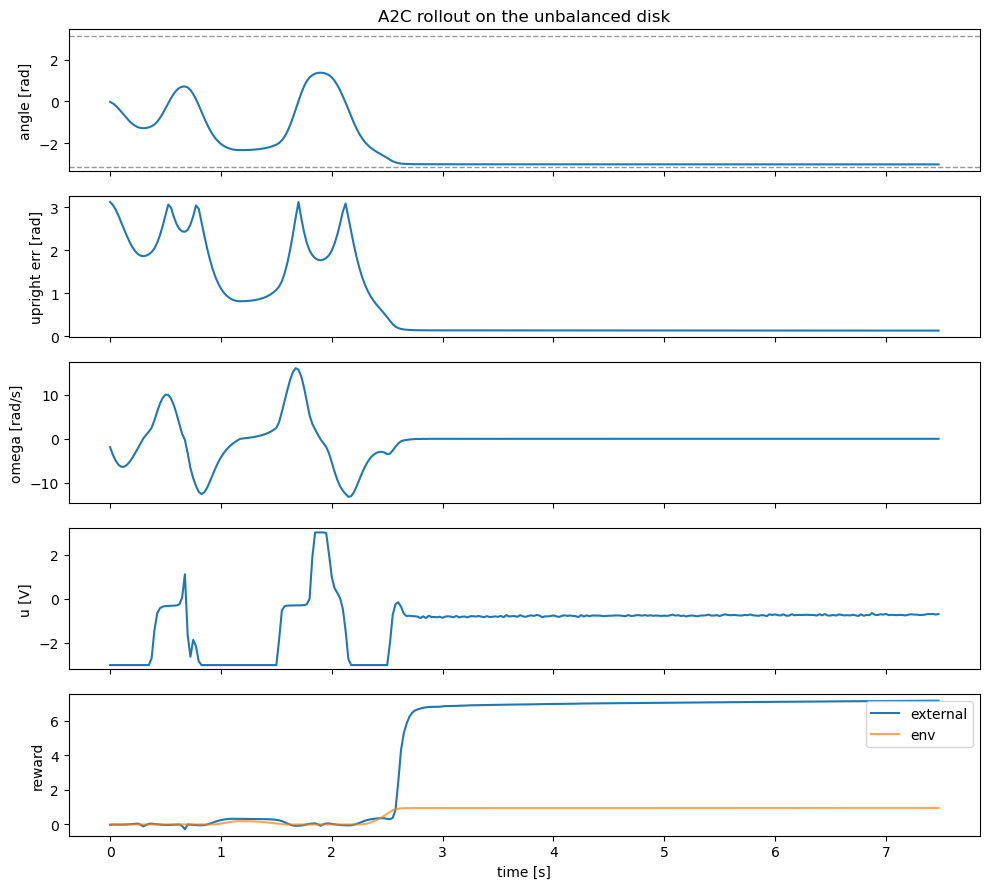

In [4]:
time_axis = np.arange(len(rewards)) * 0.025

fig, axs = plt.subplots(5, 1, figsize=(10, 9), sharex=True)
axs[0].plot(time_axis, angles)
axs[0].axhline(np.pi, color="k", linestyle="--", linewidth=1, alpha=0.4)
axs[0].axhline(-np.pi, color="k", linestyle="--", linewidth=1, alpha=0.4)
axs[0].set_ylabel("angle [rad]")
axs[0].set_title("A2C rollout on the unbalanced disk")

axs[1].plot(time_axis, upright_errors)
axs[1].set_ylabel("upright err [rad]")

axs[2].plot(time_axis, omegas)
axs[2].set_ylabel("omega [rad/s]")

axs[3].plot(time_axis, actions)
axs[3].set_ylabel("u [V]")
axs[3].set_ylim(-3.2, 3.2)

axs[4].plot(time_axis, rewards, label="external")
axs[4].plot(time_axis, env_rewards, label="env", alpha=0.7)
axs[4].set_ylabel("reward")
axs[4].set_xlabel("time [s]")
axs[4].legend()

fig.tight_layout()
plt.show()


## 5. Render Longer Simulation


In [5]:
sim_rewards, sim_actions, sim_infos = disk_rl.rollout(
    model,
    max_steps=SIMULATION_STEPS,
    deterministic=True,
    render=True,
)
print_rollout_summary("rendered simulation", sim_rewards, sim_actions, sim_infos)


objc[99740]: Class SDLApplication is implemented in both /Users/chouzk/miniforge3/envs/ml4sc/lib/python3.12/site-packages/cv2/.dylibs/libSDL2-2.0.0.dylib (0x14d3b0890) and /Users/chouzk/miniforge3/envs/ml4sc/lib/python3.12/site-packages/pygame/.dylibs/libSDL2-2.0.0.dylib (0x32d2712c8). This may cause spurious casting failures and mysterious crashes. One of the duplicates must be removed or renamed.
objc[99740]: Class SDLAppDelegate is implemented in both /Users/chouzk/miniforge3/envs/ml4sc/lib/python3.12/site-packages/cv2/.dylibs/libSDL2-2.0.0.dylib (0x14d3b08e0) and /Users/chouzk/miniforge3/envs/ml4sc/lib/python3.12/site-packages/pygame/.dylibs/libSDL2-2.0.0.dylib (0x32d271318). This may cause spurious casting failures and mysterious crashes. One of the duplicates must be removed or renamed.
objc[99740]: Class SDLTranslatorResponder is implemented in both /Users/chouzk/miniforge3/envs/ml4sc/lib/python3.12/site-packages/cv2/.dylibs/libSDL2-2.0.0.dylib (0x14d3b0958) and /Users/chouzk/mi

=== rendered simulation ===
steps: 1200
external return: 8057.23
environment return: 1060.91
mean upright error: 0.271 rad
final upright error: 0.124 rad
max |omega|: 16.02 rad/s
max |u|: 3.00 V


## Optional: Load Existing Model


In [6]:
# Use this instead of training if you already have a saved model.
MODEL_PATH = Path(MODEL_PATH)
if MODEL_PATH.suffix == ".zip":
    MODEL_PATH = MODEL_PATH.with_suffix("")
print(f"loading model from: {MODEL_PATH}.zip")
model = A2C.load(MODEL_PATH, device=DEVICE)
rewards, actions, infos = disk_rl.rollout(model, max_steps=EPISODE_STEPS, deterministic=True, render=False)
print_rollout_summary("loaded model rollout", rewards, actions, infos)


=== loaded model rollout ===
steps: 300
external return: 1378.41
environment return: 195.60
mean upright error: 0.708 rad
final upright error: 0.130 rad
max |omega|: 16.02 rad/s
max |u|: 3.00 V
